# Loading Imagenet model and its classes

In [137]:
# Loading imagenet classes file
import requests
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
response = requests.get(url)
with open("imagenet_classes.txt", "w") as f:
    f.write(response.text)

In [138]:
# Saving labels from text file in labels list
with open("imagenet_classes.txt") as f:
  labels = [line.strip() for line in f.readlines()]

In [ ]:
import torch
import torchvision.models as models

# Loading pretrained GoogleNet model
weights = models.GoogLeNet_Weights.IMAGENET1K_V1
model = models.googlenet(weights=weights)
model.eval()

# Making initial prediction

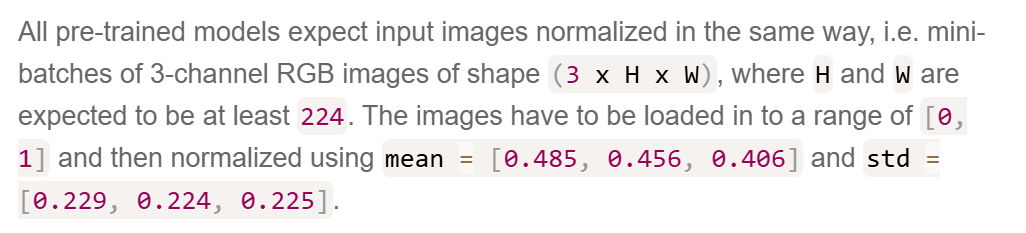

In [140]:
import torchvision.transforms as transforms

# transformations for input image
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [141]:
from PIL import Image

# Loading image and transforming it
img_path = 'cat.jpg'
image = Image.open(img_path)
image_tensor = transform(image)
print(image_tensor.shape)

image_tensor = image_tensor.unsqueeze(0) # Adding batch dimension
print(image_tensor.shape)

torch.Size([3, 224, 224])
torch.Size([1, 3, 224, 224])


In [142]:
# Make initial prediction
with torch.no_grad():
  outputs = model(image_tensor)
  print(f"outputs shape : {outputs.shape}") # shows (batch_size, num_classes)
  probabilities = torch.nn.functional.softmax(outputs, dim=1) # Apply softmax across class dimension
  print(f"probabilities shape : {probabilities.shape}")
  confidence, predicted_class = torch.max(probabilities, dim=1)

print(confidence)
print(predicted_class)

outputs shape : torch.Size([1, 1000])
probabilities shape : torch.Size([1, 1000])
tensor([0.4287])
tensor([285])


In [143]:
# Display predicted class and the confidence score
predicted_class = labels[predicted_class.item()]
confidence_percentage = confidence.item() * 100
print(f"Predicted class: {predicted_class}, Confidence: {confidence_percentage:.2f}%")

Predicted class: Egyptian cat, Confidence: 42.87%


torch.Size([1, 3, 224, 224])
(224, 224, 3)


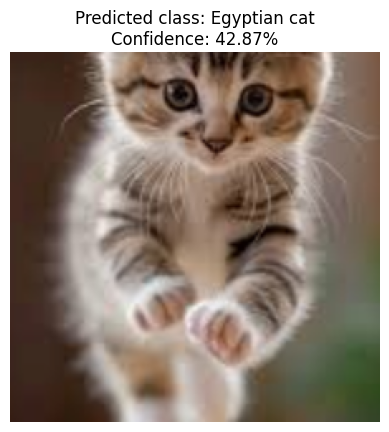

In [144]:
import numpy as np
import matplotlib.pyplot as plt

# Display image with prediction and confidence
print(image_tensor.shape)

# permute(1, 2, 0) -> reorders dimensions from (3, 224, 224) to (224, 224, 3)
image_np = image_tensor.squeeze(0).permute(1, 2, 0).detach().numpy()
print(image_np.shape)

# clip(0, 1) -> matplotlib expects values in range 0, 1
image_np = np.clip(image_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)

plt.imshow(image_np)
plt.title(f"Predicted class: {predicted_class}\nConfidence: {confidence_percentage:.2f}%")
plt.axis('off')
plt.show()

In [145]:
# Get Top 5 predictions
top5_prob, top5_id = torch.topk(probabilities, 5)
print(top5_prob)
print(top5_id)

tensor([[0.4287, 0.1889, 0.1477, 0.0350, 0.0072]])
tensor([[285, 282, 281, 287, 283]])


In [146]:
# Display top 5 predictions
for i in range(5):
  print(f"{labels[top5_id[0][i]]}: {top5_prob[0][i]* 100:.2f}%")

Egyptian cat: 42.87%
tiger cat: 18.89%
tabby: 14.77%
lynx: 3.50%
Persian cat: 0.72%


# Computing gradient for adversarial examples

In [147]:
def compute_gradient(model, image, intended_outcome):
  # Set the model to evaluation mode
  model.eval()

  # Ensure gradients are enabled
  image.requires_grad = True

  # Forward pass: compute predicted y by passing image to the model
  outputs = model(image)

  # Get the probability
  probs = torch.nn.functional.softmax(outputs, dim=1)

  # Zero all existing gradients
  model.zero_grad()

  # Create a one-hot tensor for the intended outcome
  one_hot = torch.zeros_like(probs)
  one_hot[0][intended_outcome] = 1

  # Backward pass: compute gradients with respect to the intended outcome
  outputs.backward(gradient=one_hot)

  # Get the gradients of the input image
  gradient = image.grad.data

  return gradient

In [148]:
# Defining the intended outcome
intended_outcome = 'leopard'
if intended_outcome in labels:
  outcome_index = labels.index(intended_outcome)

gradient = compute_gradient(model, image_tensor, outcome_index)

In [149]:
gradient.shape

torch.Size([1, 3, 224, 224])

In [150]:
# Make prediction
with torch.no_grad():
  outputs = model(image_tensor + 20 * gradient) # 20 is the scaling factor
  probabilities = torch.nn.functional.softmax(outputs, dim=1)
  confidence, predicted_class = torch.max(probabilities, dim=1)

  modified_image_tensor = image_tensor + 20 * gradient
  modified_image_tensor = modified_image_tensor.clamp(0, 1)

  # Create a new tensor from the modified image tensor
  modified_image_tensor = modified_image_tensor.detach().clone().requires_grad_()

In [151]:
# Top 5 probabilites
top5_prob, top5_id = torch.topk(probabilities, 5)
for i in range(5):
  print(f"{labels[top5_id[0][i]]}: {top5_prob[0][i] * 100:.2f}%")

meerkat: 52.86%
Madagascar cat: 15.93%
mongoose: 9.12%
Egyptian cat: 3.16%
tiger cat: 1.42%


In [152]:
# Convert the modified tensor back to a numpy array for display
modified_image_np = modified_image_tensor.squeeze(0).permute(1, 2, 0).detach().numpy()
applied_gradient = 20 * gradient

gradient_image_np = applied_gradient.squeeze(0).permute(1, 2, 0).detach().numpy()
modified_image_np = np.clip(modified_image_np *1.5* [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)

predicted_class_modified = labels[predicted_class.item()]
confidence_percentage_modified = confidence.item() * 100

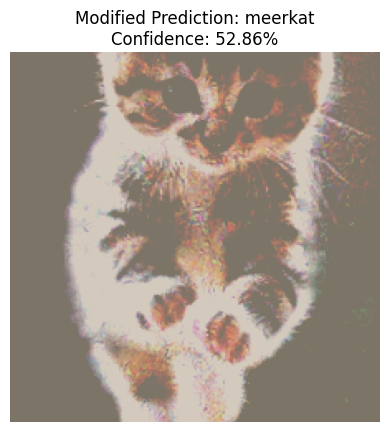

In [153]:
# Display the modified image with the prediction and confidence
import matplotlib.pyplot as plt
plt.imshow(modified_image_np)
plt.title(f"Modified Prediction: {predicted_class_modified}\nConfidence: {confidence_percentage_modified:.2f}%")
plt.axis('off')
plt.show()

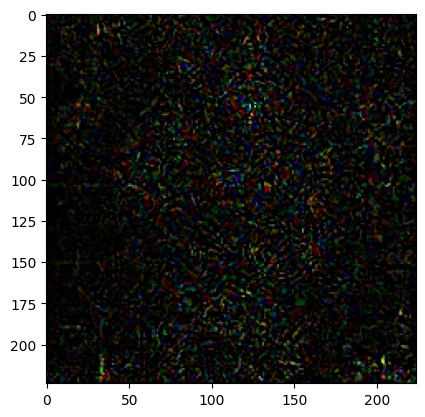

In [154]:
# Display Noise image
plt.imshow(gradient_image_np)